## **1. Chargement et inspection des données**

In [1]:
# !pip install -U \
# torch \
# torchvision \
# datasets \
# transformers \
# peft \
# accelerate

In [1]:
from datasets import load_dataset

# Charger l'ensemble de données tweet_eval avec la configuration des sentiments
dataset = load_dataset('cardiffnlp/tweet_eval', 'sentiment')

print("Répartition des données :")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Répartition des données :
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


In [2]:
label_map = {
    0: 'négatif',
    1: 'neutre',
    2: 'positif'
}

print("Répartition des classes par ensemble :")
for split, data in dataset.items():
    print(f"\n--- {split.capitalize()} set ---")
    labels = [label_map[label] for label in data['label']]
    from collections import Counter
    label_counts = Counter(labels)
    for label, count in label_counts.items():
        print(f"{label}: {count} ({round(count/len(labels),2)})")

    # Vérifier la présence des 3 étiquettes
    if set(label_counts.keys()) != set(label_map.values()):
        print("Attention : toutes les 3 étiquettes (négatif, neutre, positif) ne sont pas présentes dans cet ensemble.")

Répartition des classes par ensemble :

--- Train set ---
positif: 17849 (0.39)
neutre: 20673 (0.45)
négatif: 7093 (0.16)

--- Test set ---
neutre: 5937 (0.48)
positif: 2375 (0.19)
négatif: 3972 (0.32)

--- Validation set ---
neutre: 869 (0.43)
positif: 819 (0.41)
négatif: 312 (0.16)


In [3]:
examples_per_label = {}
for label_id, label_name in label_map.items():
    examples_per_label[label_name] = []

# Collecter deux exemples de tweets par étiquette à partir de l'ensemble d'entraînement
for example in dataset['train']:
    label_id = example['label']
    label_name = label_map[label_id]
    if len(examples_per_label[label_name]) < 2:
        examples_per_label[label_name].append(example['text'])
    # Vérifions si nous avons suffisamment d'exemples pour toutes les étiquettes
    if all(len(v) == 2 for v in examples_per_label.values()):
        break

print("Exemples de tweets par étiquette (2 par étiquette) :")
for label, tweets in examples_per_label.items():
    print(f"\n--- {label.capitalize()} ---")
    for i, tweet in enumerate(tweets):
        print(f"Exemple {i+1}: {tweet}")

Exemples de tweets par étiquette (2 par étiquette) :

--- Négatif ---
Exemple 1: So disappointed in wwe summerslam! I want to see john cena wins his 16th title
Exemple 2: That sucks if you have to take the SATs tomorrow

--- Neutre ---
Exemple 1: "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
Exemple 2: Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.

--- Positif ---
Exemple 1: "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
Exemple 2: @user Alciato: Bee will invest 150 million in January, another 200 in the Summer and plans to bring Messi by 2017"


## **2. Pipeline de tokenisation**


In [4]:
from transformers import AutoTokenizer

# Initialiser AutoTokenizer avec distilbert-base-uncased
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

### **Fonction de prétraitement**

Cette fonction prend un lot de tweets, les tokenize en utilisant le `tokenizer` initialisé, et s'assure qu'ils sont tronqués et complétés à 128 tokens. Elle retourne les `input_ids`, `attention_mask` et `labels`.

In [5]:
def preprocess_function(examples):
    # Tronquer/compléter les tweets à 128 tokens
    tokenized_examples = tokenizer(examples['text'], truncation=True, padding='max_length', max_length=128)
    # Renommons la colonne 'label' en 'labels' pour l'entraînement avec Transformers
    tokenized_examples['labels'] = examples['label']
    return tokenized_examples


### Application du prétraitement et formatage du dataset

Nous allons maintenant appliquer cette fonction à toutes les divisions de l'ensemble de données (`train`, `test`, `validation`) et ensuite définir le format des tenseurs sur `torch`.

In [6]:
# Mappons l'ensemble de données avec batched=True
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# Mélangeons l'ensemble d'entraînement
tokenized_dataset['train'] = tokenized_dataset['train'].shuffle(seed=42)

# Créer set_format("torch")
tokenized_dataset.set_format("torch")

print("Dataset tokenisé et formaté :")
print(tokenized_dataset)
print("\nUn exemple d'entrée tokenisée (train) :")
print(tokenized_dataset['train'][0])

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset tokenisé et formaté :
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 45615
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 12284
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 2000
    })
})

Un exemple d'entrée tokenisée (train) :
{'text': 'Few more hours to iPhone 6s launch and im still using the 4th generation ^_^', 'label': tensor(2), 'input_ids': tensor([  101,  2261,  2062,  2847,  2000, 18059,  1020,  2015,  4888,  1998,
        10047,  2145,  2478,  1996,  4343,  4245,  1034,  1035,  1034,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,   

## **3. Fine-Tuning Setup**

### Chargement du modèle pré-entraîné et configuration LoRA pour la classification de séquences

Nous allons utiliser `AutoModelForSequenceClassification` et configurer LoRA avec les modules cibles appropriés pour DistilBERT et le type de tâche `SEQ_CLS`.

In [8]:
%pip install peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 12.8 MB/s eta 0:00:00


In [22]:
from transformers import AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model

# Charger AutoModelForSequenceClassification avec le nombre de labels approprié
# num_labels est le nombre de classes de sentiment dans notre dataset (négatif, neutre, positif)
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=len(label_map),
    output_attentions=True # Add this line to ensure attentions are outputted
)

# Définir la configuration LoRA pour ce modèle (classification de séquences)
lora_config = LoraConfig(
    r=1,
    lora_alpha=0.01,
    target_modules=['q_lin', 'k_lin', 'v_lin'], # Modules cibles pour DistilBERT
    lora_dropout=0.1,
    bias="none",
    task_type="SEQ_CLS" # Type de tâche pour la classification de séquences
)

# Appliquer la configuration LoRA au modèle de base
peft_model = get_peft_model(model, lora_config)

print("Modèle PEFT chargé et configuré pour la classification :")
peft_model.print_trainable_parameters()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modèle PEFT chargé et configuré pour la classification :
trainable params: 620,547 || all params: 67,576,326 || trainable%: 0.9183


### Définition de la fonction `compute_metrics`

Cette fonction calculera l'exactitude (accuracy) et le F1-score macro pour évaluer la performance du modèle pendant l'entraînement.

In [10]:
%pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.3 MB/s eta 0:00:00


In [11]:
import numpy as np
import evaluate

# Charger les métriques d'exactitude et de F1-score
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")

    return {"accuracy": accuracy["accuracy"], "f1_macro": f1["f1"]}


### Arguments d'entraînement et initialisation du Trainer

Nous allons configurer les `TrainingArguments` avec les paramètres spécifiés et initialiser le `Trainer`.

In [12]:
from transformers import TrainingArguments, Trainer

# Définir les arguments d'entraînement
training_args = TrainingArguments(
    output_dir="./results", # Répertoire de sortie pour les checkpoints et les logs
    learning_rate=5e-5,
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",      # Évaluer à chaque époque
    save_strategy="epoch",      # Sauvegarder à chaque époque
    load_best_model_at_end=False, # Temporairement désactivé pour diagnostiquer la FileNotFoundError
    metric_for_best_model="f1_macro", # Utiliser le F1-score macro pour déterminer le meilleur modèle
    report_to="none",           # Désactiver les intégrations de rapport comme wandb
    optim="adamw_torch"         # Utiliser l'optimiseur AdamW non fusionné compatible avec XLA
)

# Initialiser le Trainer
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    # Suppression de l'argument 'tokenizer' car le dataset est déjà tokenisé et paddé
    compute_metrics=compute_metrics,
)

print("Trainer initialisé avec le modèle PEFT et le jeu de données tokenisé.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer initialisé avec le modèle PEFT et le jeu de données tokenisé.


### **Entraînement du modèle**

Maintenant, nous pouvons lancer l'entraînement du modèle. Cela peut prendre un certain temps.

In [13]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.781726,0.793006,0.625500,0.567517
2,0.773634,0.769802,0.647000,0.612137
3,0.772143,0.765469,0.647000,0.609878


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


TrainOutput(global_step=4278, training_loss=0.802761079552799, metrics={'train_runtime': 397.0915, 'train_samples_per_second': 344.747, 'train_steps_per_second': 10.773, 'total_flos': 4597173715069440.0, 'train_loss': 0.802761079552799, 'epoch': 3.0})

### **Sauvegarde du modèle LoRA fine-tuné**

Après l'entraînement, nous allons sauvegarder le modèle fine-tuné.

In [14]:
import torch
import os

# Sauvegarder le modèle PEFT fine-tuné
output_dir_peft = "./peft_model_sentiment"

# Créer le répertoire s'il n'existe pas
os.makedirs(output_dir_peft, exist_ok=True)

# Sauvegarder l'état du modèle en utilisant torch.save comme contournement
torch.save(trainer.model.state_dict(), os.path.join(output_dir_peft, "pytorch_model.bin"))

# Sauvegarder également la configuration PEFT si nécessaire (bien que save_pretrained le fasse déjà pour lora_config)
# Si vous n'avez pas besoin de recharger spécifiquement lora_config, cette ligne n'est pas strictement nécessaire
trainer.model.config.save_pretrained(output_dir_peft)

print(f"Modèle PEFT (state_dict) sauvegardé dans : {os.path.join(output_dir_peft, 'pytorch_model.bin')}")
print(f"Configuration du modèle sauvegardée dans : {output_dir_peft}")

Modèle PEFT (state_dict) sauvegardé dans : ./peft_model_sentiment/pytorch_model.bin
Configuration du modèle sauvegardée dans : ./peft_model_sentiment


## **4. Évaluation du modèle**

Nous allons évaluer le modèle fine-tuné sur l'ensemble de validation pour obtenir la précision (accuracy) et le score F1.

In [15]:
# Évaluation sur la division de validation
validation_results = trainer.evaluate(eval_dataset=tokenized_dataset["validation"])
print("Résultats de l'évaluation sur l'ensemble de validation :")
print(validation_results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.772143,0.765469,3,0.647000,0.609878


Résultats de l'évaluation sur l'ensemble de validation :
{'eval_loss': 0.7654691338539124, 'eval_accuracy': 0.647, 'eval_f1_macro': 0.6098777765444432}


In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


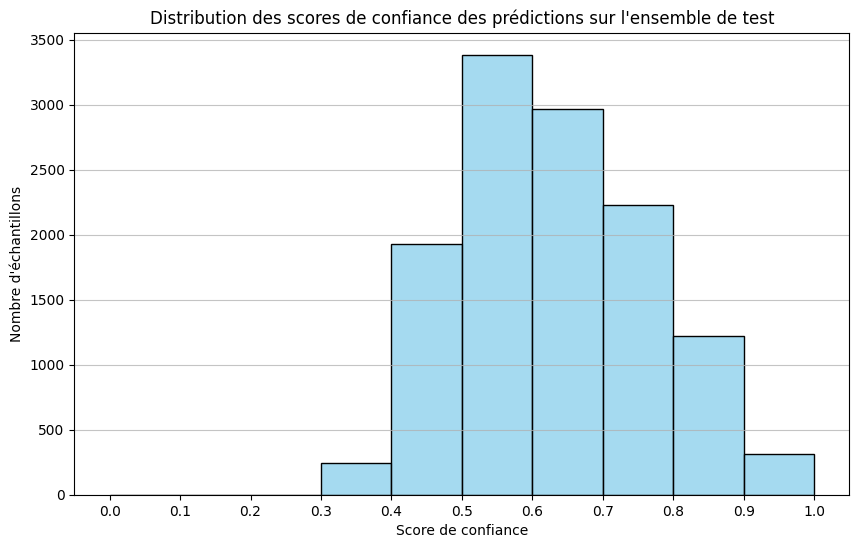

In [17]:
# Effectuons des prédictions sur l'ensemble de test en utilisant le modèle du trainer
predictions_output = trainer.predict(test_dataset=tokenized_dataset["test"])
logits = predictions_output.predictions

# Convertir les logits en scores de probabilité (softmax)
probabilities = F.softmax(torch.tensor(logits), dim=-1).numpy()

# Obtenir les classes prédites
predicted_classes = np.argmax(probabilities, axis=1)

# Obtenir les scores de confiance pour les classes prédites
confidence_scores = probabilities[np.arange(len(predicted_classes)), predicted_classes]

# Tracer un histogramme des scores de confiance
plt.figure(figsize=(10, 6))
sns.histplot(confidence_scores, bins=np.arange(0, 1.1, 0.1), kde=False, color='skyblue', edgecolor='black')
plt.title('Distribution des scores de confiance des prédictions sur l\'ensemble de test')
plt.xlabel('Score de confiance')
plt.ylabel('Nombre d\'échantillons')
plt.xticks(np.arange(0, 1.1, 0.1))
plt.grid(axis='y', alpha=0.75)
plt.show()

### **5. Inspection d'attention**

### Inspection de l'attention

Nous allons inspecter comment le modèle "prête attention" aux différents mots d'un tweet d'exemple. Pour cela, nous allons:

1.  **Choisir un tweet d'exemple** (par exemple, un tweet négatif).
2.  **Tokeniser le tweet**.
3.  **Faire passer le tweet tokenisé au modèle** et récupérer les poids d'attention de la dernière couche.
4.  **Calculer la moyenne** des poids d'attention sur toutes les têtes pour le jeton `[CLS]` (le premier jeton, qui représente le sens global de la phrase).
5.  **Visualiser** cette attention à l'aide d'un graphique à barres.
6.  **Interpréter** les résultats pour comprendre quels mots ont été les plus importants pour la prédiction du sentiment.

Tweet d'exemple: So disappointed in wwe summerslam! I want to see john cena wins his 16th title


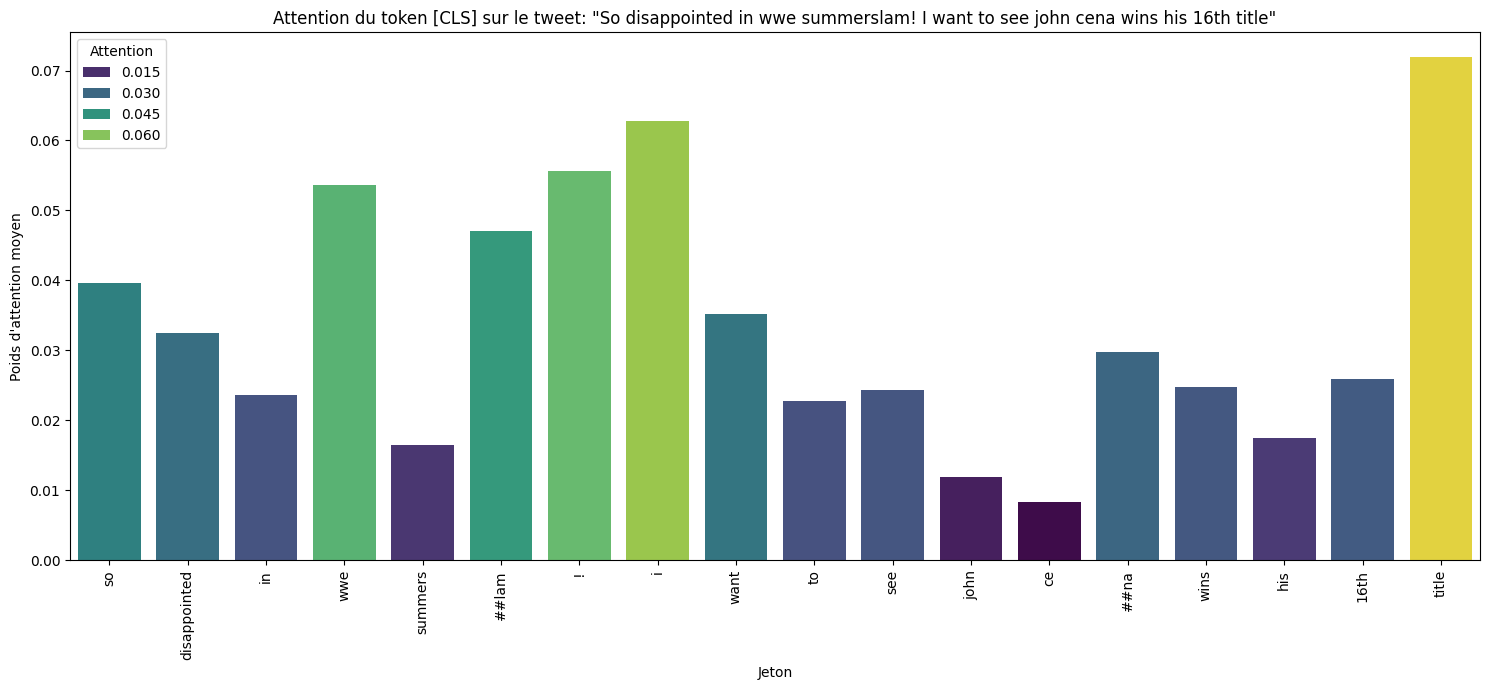

In [25]:
from transformers import AutoModelForSequenceClassification
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Choisissons un tweet négatif
example_tweet = examples_per_label['négatif'][0]
print(f"Tweet d'exemple: {example_tweet}")

# Tokenization du tweet
inputs = tokenizer(example_tweet, return_tensors='pt', truncation=True, padding='max_length', max_length=128)

device = peft_model.device
inputs = {k: v.to(device) for k, v in inputs.items()}

# Assurons nous que le modèle est en mode évaluation
peft_model.eval()

# Effectuez un passage avant pour obtenir les poids d'attention
with torch.no_grad():
    outputs = peft_model(**inputs, output_attentions=True)
attentions = outputs.attentions[-1] # Attention de la dernière couche

cls_attention = attentions[0, :, 0, :]

# Moyenne sur toutes les têtes d'attention
averaged_cls_attention = cls_attention.mean(dim=0).cpu().numpy()

# Obtenez les jetons pour l'axe X du graphique
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Créez un DataFrame pour faciliter le traçage
attention_df = pd.DataFrame({
    'Token': tokens,
    'Attention': averaged_cls_attention
})

# Filtrons les tokens spéciaux comme [CLS], [SEP], [PAD] pour une meilleure visualisation et gardons uniquement les tokens ayant une attention significative si nécessaire
attention_df = attention_df[~attention_df['Token'].isin(['[CLS]', '[SEP]', '[PAD]'])]

plt.figure(figsize=(15, 7),dpi = 100)
sns.barplot(x='Token', y='Attention', data=attention_df, palette='viridis',hue='Attention')
plt.title(f'Attention du token [CLS] sur le tweet: "{example_tweet}"')
plt.xlabel('Token')
plt.ylabel('Poids d\'attention moyen')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### **Interprétation de l'attention**

Le graphique à barres que vous avez généré montre les poids d'attention moyens du token [CLS] pour chaque mot du tweet d'exemple: **So disappointed in wwe summerslam! I want to see john cena wins his 16th title**.

Les barres plus hautes indiquent que le modèle a accordé plus d'importance à ces mots lors de la formation de sa représentation globale du tweet pour la classification du sentiment. Pour ce tweet spécifique, nous pouvons observer que les mots qui reçoivent les poids d'attention les plus élevés sont:

* "title": Avec un poids d'attention d'environ 0.071, c'est le mot qui ressort le plus.
* "i": Avec un poids d'attention d'environ 0.062.
* "!": Le point d'exclamation, avec un poids d'attention d'environ 0.055.
* "wwe": Avec un poids d'attention d'environ 0.053.  

Il est intéressant de noter que le mot "disappointed" (environ 0.038) a également un poids significatif, ce qui est logique pour un tweet négatif. Cependant, la forte attention portée à "title" et "i" ainsi qu'à "wwe" pourrait indiquer que le modèle ne se concentre pas uniquement sur les mots porteurs de sentiment directs, mais aussi sur le contexte général de l'énoncé, y compris les entités mentionnées et les marqueurs d'emphase (comme le point d'exclamation). La phrase "I want to see john cena wins his 16th title" bien que non négative en soi, est le désir exprimé suite à la déception, et le mot "title" en est un élément clé.